# YOLO Document Layout Detection + SALG

## Setup Directories For Kaggle

In [ ]:
import os, torch

# Kaggle working dir has 100 GB SSD — no Drive mount needed
BASE      = '/kaggle/working/doclayout_yolo'
DATA_DIR  = f'{BASE}/dataset'
MODEL_DIR = f'{BASE}/models'
OUT_DIR   = f'{BASE}/runs'

for d in [DATA_DIR, MODEL_DIR, OUT_DIR,
          f'{DATA_DIR}/images/train', f'{DATA_DIR}/images/val',
          f'{DATA_DIR}/labels/train', f'{DATA_DIR}/labels/val']:
    os.makedirs(d, exist_ok=True)

# Verify dual GPU
n_gpu = torch.cuda.device_count()
for i in range(n_gpu):
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} — {mem:.1f} GB')

assert n_gpu >= 1, 'No GPU found — enable GPU in Kaggle Accelerator settings'
print(f'\n{n_gpu} GPU(s) ready. Base: {BASE}')

  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB

2 GPU(s) ready. Base: /kaggle/working/doclayout_yolo


## Install Dependencies

In [ ]:
# Kaggle has most packages pre-installed; ultralytics may need upgrading
!pip install -q --upgrade ultralytics huggingface_hub datasets

import torch
from ultralytics import YOLO
print(f'ultralytics ready | torch {torch.__version__} | CUDA {torch.version.cuda}')

ultralytics ready | torch 2.10.0+cu128 | CUDA 12.8


##  Download YOLOv from HuggingFace

In [ ]:
from huggingface_hub import hf_hub_download
from pathlib import Path

# 'n' = nano  |  's' = small  |  'm' = medium
# With dual T4 (30 GB total) we can comfortably run 's'
MODEL_SIZE = 's'

model_filename = f'yolo26{MODEL_SIZE}_doc_layout.pt'
model_path     = Path(MODEL_DIR) / model_filename

if not model_path.exists():
    print(f'Downloading {model_filename}...')
    hf_hub_download(
        repo_id   = 'Armaggheddon/yolo26-document-layout',
        filename  = model_filename,
        repo_type = 'model',
        local_dir = MODEL_DIR
    )
    print('Downloaded.')
else:
    print(f'Already exists: {model_path}')

yolo26s_doc_layout.pt:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

Downloaded.


##  Stream DocLayNet to Local SSD
- Defines 11 document layout classes and maps them to IDs
- Converts COCO bounding boxes → YOLO normalized format
- Streams dataset from Hugging Face (no full download)
- Saves images as compressed JPEGs
- Creates YOLO label `.txt` files for each image
- Skips already processed files (resume support)
- Runs train and validation processing in parallel
- Supports fast mode (subset) or full dataset processing

In [ ]:
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset
from concurrent.futures import ThreadPoolExecutor

CLASSES = [
    'Caption',        # 0
    'Footnote',       # 1
    'Formula',        # 2
    'List-item',      # 3
    'Page-footer',    # 4
    'Page-header',    # 5
    'Picture',        # 6
    'Section-header', # 7
    'Table',          # 8
    'Text',           # 9
    'Title'           # 10
]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
N_CLASSES   = len(CLASSES)

def convert_bbox_to_yolo(bbox, img_w, img_h):
    """COCO [x, y, w, h] pixels → YOLO [cx, cy, w, h] normalised."""
    x, y, w, h = bbox
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    bw = w / img_w
    bh = h / img_h
    return max(0, min(1, cx)), max(0, min(1, cy)), max(0, min(1, bw)), max(0, min(1, bh))

def process_split(hf_split, folder_name, max_samples=None):
    img_dir = Path(DATA_DIR) / 'images' / folder_name
    lbl_dir = Path(DATA_DIR) / 'labels' / folder_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    already_done = len(list(img_dir.glob('*.jpg')))
    if already_done > 0:
        print(f'  [{folder_name}] {already_done} files exist — resuming.')

    ds = load_dataset(
        'docling-project/DocLayNet-v1.2',
        split=hf_split,
        streaming=True,
        trust_remote_code=True
    )

    saved = skipped = 0
    for idx, sample in enumerate(tqdm(ds, desc=folder_name)):
        if max_samples and idx >= max_samples:
            break

        stem     = f'{folder_name}_{idx:06d}'
        img_path = img_dir / f'{stem}.jpg'
        lbl_path = lbl_dir / f'{stem}.txt'

        if img_path.exists() and lbl_path.exists():
            skipped += 1
            continue

        img    = sample['image']
        img_w, img_h = img.size
        # JPEG quality=85 saves ~15% space vs 90 with negligible visual loss
        img.convert('RGB').save(img_path, 'JPEG', quality=85, optimize=True)

        lines        = []
        bboxes       = sample.get('bboxes', [])
        category_ids = sample.get('category_id', [])
        for bbox, cls_id in zip(bboxes, category_ids):
            if cls_id < 0 or cls_id >= N_CLASSES:
                continue
            cx, cy, bw, bh = convert_bbox_to_yolo(bbox, img_w, img_h)
            if bw > 0 and bh > 0:
                lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')

        lbl_path.write_text('\n'.join(lines))
        saved += 1

    print(f'  [{folder_name}] {saved} new  {skipped} skipped  total {saved+skipped}')

# Config
FAST_EXPERIMENT = True   # ← Set False for full dataset
train_limit = 5000 if FAST_EXPERIMENT else None
val_limit   = 1000 if FAST_EXPERIMENT else None
print(f'Mode: {"FAST" if FAST_EXPERIMENT else "FULL"}')

# ── Parallel streaming: train + val at the same time ────────────
with ThreadPoolExecutor(max_workers=2) as ex:
    ft = ex.submit(process_split, 'train',      'train', train_limit)
    fv = ex.submit(process_split, 'validation', 'val',   val_limit)
    ft.result()
    fv.result()

print('\nDataset ready.')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'docling-project/DocLayNet-v1.2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'docling-project/DocLayNet-v1.2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Mode: FAST


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

train: 0it [00:00, ?it/s]

val: 0it [00:00, ?it/s]

  [val] 1000 new  0 skipped  total 1000
  [train] 5000 new  0 skipped  total 5000

Dataset ready.


## Write YAML Config


In [ ]:
import yaml

yaml_cfg = {
    'path'  : DATA_DIR,
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 11,
    'names' : CLASSES
}

yaml_path = f'{BASE}/doclaynet.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False)

print(f'YAML saved: {yaml_path}')
print(yaml.dump(yaml_cfg))

YAML saved: /kaggle/working/doclayout_yolo/doclaynet.yaml
names:
- Caption
- Footnote
- Formula
- List-item
- Page-footer
- Page-header
- Picture
- Section-header
- Table
- Text
- Title
nc: 11
path: /kaggle/working/doclayout_yolo/dataset
train: images/train
val: images/val



## Fine-tune

Train YOLO model

### What it does
- Adjusts learning rate based on batch size (linear scaling)
- Loads YOLO model and starts training
- Uses mixed precision (AMP) and disk caching for speed
- Applies learning schedule (warmup + cosine decay)
- Uses AdamW optimizer with label smoothing
- Applies document-safe augmentations (no rotation/flip)
- Saves checkpoints periodically and stops early if no improvement
- Outputs best trained model path

In [ ]:
import torch
from ultralytics import YOLO

n_gpu = 2
BATCH = 4 * n_gpu

LR0   = 0.001 * (BATCH / 4)
DEVICE = ','.join(str(i) for i in range(n_gpu))

print(f'GPUs: {n_gpu}  |  batch: {BATCH}  |  lr0: {LR0:.4f}  |  device: {DEVICE}')

model = YOLO(str(model_path))

results = model.train(
    data    = yaml_path,
    epochs  = 30,
    imgsz   = 1280,
    batch   = BATCH,
    device  = DEVICE,

    # Speed
    amp     = True,
    cache   = 'disk',     # Kaggle SSD is fast; safer than RAM on 13 GB machine
    workers = 4 * n_gpu,  # 4 dataloader workers per GPU

    # Learning schedule — scaled for larger batch
    lr0           = LR0,
    lrf           = 0.01,
    warmup_epochs = 5,      # Longer warmup for bigger batch
    cos_lr        = True,

    # Accuracy
    optimizer       = 'AdamW',
    weight_decay    = 0.0005,
    label_smoothing = 0.05,

    # Augmentation (document-safe: no rotation, no flips)
    mosaic     = 1.0,
    copy_paste = 0.3,
    degrees    = 0.0,
    fliplr     = 0.0,
    flipud     = 0.0,
    hsv_h      = 0.015,
    hsv_s      = 0.3,
    hsv_v      = 0.3,

    # Persistence
    project     = OUT_DIR,
    name        = f'yolo26{MODEL_SIZE}_doclaynet_kaggle',
    save_period = 5,
    patience    = 15,
)

print('\nTraining complete!')
print(f'   Best model: {OUT_DIR}/yolo26{MODEL_SIZE}_doclaynet_kaggle/weights/best.pt')

GPUs: 2  |  batch: 8  |  lr0: 0.0020  |  device: 0,1
WARNING  'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.33  Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/doclayout_yolo/doclaynet.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ra

## Evaluate on Validation Set
- Loads best trained model
- Runs validation on validation split
- Computes key metrics: mAP@50, mAP@50-95, Precision, Recall
- Displays overall performance
- Shows per-class mAP@50 with simple bar visualization

In [ ]:
from ultralytics import YOLO

best_model_path = f'{OUT_DIR}/yolo26{MODEL_SIZE}_doclaynet_kaggle/weights/best.pt'

model_eval = YOLO(best_model_path)

# Eval uses only GPU 0 — DDP not needed for validation
metrics = model_eval.val(
    data    = yaml_path,
    imgsz   = 1280,
    batch   = 8,
    device  = 0,
    split   = 'val',
    project = OUT_DIR,
    name    = 'eval',
)

print('\nValidation Results:')
print(f'  mAP@50    : {metrics.box.map50:.4f}')
print(f'  mAP@50-95 : {metrics.box.map:.4f}')
print(f'  Precision : {metrics.box.mp:.4f}')
print(f'  Recall    : {metrics.box.mr:.4f}')

print('\nPer-class mAP@50:')
for cls_name, ap in zip(CLASSES, metrics.box.ap50):
    bar = '█' * int(ap * 30)
    print(f'  {cls_name:<16} {bar:<30} {ap:.3f}')

Ultralytics 8.4.33 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,469,437 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access (ping: 0.0±0.0 ms, read: 2007.7±514.8 MB/s, size: 150.6 KB)
val: Scanning /kaggle/working/doclayout_yolo/dataset/labels/val.cache... 1000 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 209.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 2.2it/s 57.1s0.4ss
                   all       1000      13501      0.721      0.711       0.76      0.606
              Footnote        102        261      0.581      0.636      0.695      0.602
               Formula          7         17      0.518      0.118      0.198      0.156
           Page-footer        194       1166      0.785      0.849      0.895      0.763
           Page-header        749        876      0.786      0.864      0.861      0.461
               P

## Semantic-Aware Layout Grouping (SALG)
- Defines `Detection` (box, class, confidence) with helper properties
- Defines `SemanticGroup` to hold grouped elements and bounding box
- Classifies detections into flow, float, captions, and margins
- Detects single or multi-column layout
- Clusters text elements vertically into logical groups
- Anchors captions to nearest figures/tables
- Creates semantic groups (header, section, flow, float, margin, isolated)
- Sorts groups into correct reading order

In [ ]:
import numpy as np
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional


@dataclass
class Detection:
    cls_name: str
    cls_id  : int
    conf    : float
    box     : Tuple[float, float, float, float]

    @property
    def cx(self): return (self.box[0] + self.box[2]) / 2
    @property
    def cy(self): return (self.box[1] + self.box[3]) / 2
    @property
    def w(self):  return self.box[2] - self.box[0]
    @property
    def h(self):  return self.box[3] - self.box[1]
    @property
    def area(self): return self.w * self.h


@dataclass
class SemanticGroup:
    group_type   : str
    elements     : List[Detection]
    anchor       : Optional[Detection] = None
    reading_order: int = 0

    @property
    def bbox(self):
        x1 = min(d.box[0] for d in self.elements)
        y1 = min(d.box[1] for d in self.elements)
        x2 = max(d.box[2] for d in self.elements)
        y2 = max(d.box[3] for d in self.elements)
        return x1, y1, x2, y2

    @property
    def cy(self):
        x1, y1, x2, y2 = self.bbox
        return (y1 + y2) / 2


class SALG:
    FLOAT_CLASSES   = {'Table', 'Picture', 'Formula'}
    FLOW_CLASSES    = {'Text', 'List-item'}
    HEADING_CLASSES = {'Section-header', 'Title'}
    ANCHOR_CLASSES  = {'Caption'}
    MARGIN_CLASSES  = {'Page-header', 'Page-footer', 'Footnote'}

    def __init__(self, img_h, img_w, col_gap_ratio=0.06, vert_gap_ratio=0.025,
                 caption_radius=0.20, caption_iou_x=0.30, float_merge_gap=0.01,
                 nms_iou_thresh=0.60, min_conf=0.20):
        self.img_h           = img_h
        self.img_w           = img_w
        self.col_gap         = col_gap_ratio   * img_w
        self.vert_gap        = vert_gap_ratio  * img_h
        self.caption_radius  = caption_radius  * img_h
        self.caption_iou_x   = caption_iou_x
        self.float_merge_gap = float_merge_gap * img_h
        self.nms_iou_thresh  = nms_iou_thresh
        self.min_conf        = min_conf

    def _nms(self, dets):
        if not dets: return dets
        from collections import defaultdict
        by_class = defaultdict(list)
        for d in dets: by_class[d.cls_name].append(d)
        kept = []
        for cls_dets in by_class.values():
            cls_dets = sorted(cls_dets, key=lambda d: -d.conf)
            suppressed = [False] * len(cls_dets)
            for i, d_i in enumerate(cls_dets):
                if suppressed[i]: continue
                kept.append(d_i)
                for j in range(i + 1, len(cls_dets)):
                    if not suppressed[j] and self._iou(d_i, cls_dets[j]) > self.nms_iou_thresh:
                        suppressed[j] = True
        return kept

    @staticmethod
    def _iou(a, b):
        ax1,ay1,ax2,ay2 = a.box; bx1,by1,bx2,by2 = b.box
        ix1,iy1 = max(ax1,bx1), max(ay1,by1)
        ix2,iy2 = min(ax2,bx2), min(ay2,by2)
        inter = max(0.,ix2-ix1)*max(0.,iy2-iy1)
        if inter == 0: return 0.
        union = (ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter
        return inter/union if union > 0 else 0.

    def _merge_floats(self, dets):
        if not dets: return dets
        merged_flag = [False]*len(dets)
        result = []
        dets = sorted(dets, key=lambda d: d.box[1])
        for i, d_i in enumerate(dets):
            if merged_flag[i]: continue
            group = [d_i]
            for j in range(i+1, len(dets)):
                if merged_flag[j]: continue
                d_j = dets[j]
                if d_j.cls_name != d_i.cls_name: continue
                h_overlap = min(d_i.box[2],d_j.box[2]) - max(d_i.box[0],d_j.box[0])
                if h_overlap < -self.img_w*0.05: continue
                v_gap = d_j.box[1] - max(g.box[3] for g in group)
                if v_gap < self.float_merge_gap:
                    group.append(d_j); merged_flag[j] = True
            x1=min(g.box[0] for g in group); y1=min(g.box[1] for g in group)
            x2=max(g.box[2] for g in group); y2=max(g.box[3] for g in group)
            best = max(group, key=lambda g: g.conf)
            result.append(Detection(best.cls_name, best.cls_id, best.conf, (x1,y1,x2,y2)))
        return result

    def _detect_columns(self, dets):
        if len(dets) < 4: return 1
        bins = 20
        edges = np.linspace(0, self.img_w, bins+1)
        counts, _ = np.histogram([d.cx for d in dets], bins=edges)
        mid_bin = bins//2
        central = counts[mid_bin - bins//6 : mid_bin + bins//6 + 1]
        flanks  = np.concatenate([counts[:mid_bin-bins//6], counts[mid_bin+bins//6+1:]])
        if len(central)==0 or len(flanks)==0: return 1
        valley_depth = np.mean(flanks) - np.min(central)
        return 2 if valley_depth > np.mean(counts)*0.4 else 1

    def _column_of(self, det, n_cols):
        if n_cols == 1: return 0
        return 0 if det.cx < self.img_w/2 else 1

    def _cluster_flow(self, dets):
        if not dets: return []
        sorted_dets = sorted(dets, key=lambda d: d.box[1])
        groups = [[sorted_dets[0]]]
        for det in sorted_dets[1:]:
            prev = groups[-1][-1]
            gap  = det.box[1] - prev.box[3]
            is_heading = det.cls_name in self.HEADING_CLASSES or prev.cls_name in self.HEADING_CLASSES
            if gap < self.vert_gap and not is_heading:
                groups[-1].append(det)
            else:
                groups.append([det])
        return groups

    def _anchor_captions(self, captions, floats):
        anchors = {}
        for i, cap in enumerate(captions):
            best_score, best_f = float('inf'), None
            for f in floats:
                v_dist = abs(cap.cy - f.cy)
                if v_dist >= self.caption_radius: continue
                h_overlap = min(cap.box[2],f.box[2]) - max(cap.box[0],f.box[0])
                h_ratio   = h_overlap / max(cap.w, 1e-3)
                if h_ratio < self.caption_iou_x: continue
                score = v_dist / (h_ratio + 1e-6)
                if score < best_score: best_score, best_f = score, f
            if best_f is not None: anchors[i] = best_f
        return anchors

    def _reading_key(self, g):
        x1,y1,x2,y2 = g.bbox
        cy = (y1+y2)/2
        if g.group_type == 'margin':
            return (-1,0,y1) if y1 < self.img_h*0.1 else (999,0,y1)
        col = 0 if (x2-x1) > self.img_w*0.60 else (0 if x1 < self.img_w/2 else 1)
        strip = int(cy / self.img_h * 20)
        return (strip, col, y1)

    def group(self, detections):
        detections = [d for d in detections if d.conf >= self.min_conf]
        detections = self._nms(detections)
        flow_dets    = [d for d in detections if d.cls_name in self.FLOW_CLASSES]
        heading_dets = [d for d in detections if d.cls_name in self.HEADING_CLASSES]
        float_dets   = [d for d in detections if d.cls_name in self.FLOAT_CLASSES]
        caption_dets = [d for d in detections if d.cls_name in self.ANCHOR_CLASSES]
        margin_dets  = [d for d in detections if d.cls_name in self.MARGIN_CLASSES]
        float_dets   = self._merge_floats(float_dets)
        groups = []
        all_text = flow_dets + heading_dets
        n_cols   = self._detect_columns(all_text)
        for col in range(n_cols):
            col_dets = [d for d in all_text if self._column_of(d, n_cols)==col]
            for cluster in self._cluster_flow(col_dets):
                types = {d.cls_name for d in cluster}
                gtype = 'title' if 'Title' in types else ('section' if 'Section-header' in types else 'flow')
                groups.append(SemanticGroup(group_type=gtype, elements=cluster))
        cap_anchors   = self._anchor_captions(caption_dets, float_dets)
        anchored_caps = set(cap_anchors.keys())
        for f in float_dets:
            elems = [f] + [caption_dets[ci] for ci,anch in cap_anchors.items() if anch is f]
            groups.append(SemanticGroup(group_type='float', elements=elems, anchor=f))
        for i, cap in enumerate(caption_dets):
            if i not in anchored_caps:
                groups.append(SemanticGroup(group_type='isolated_caption', elements=[cap]))
        for det in margin_dets:
            groups.append(SemanticGroup(group_type='margin', elements=[det]))
        groups.sort(key=self._reading_key)
        for i, g in enumerate(groups): g.reading_order = i
        return groups


def groups_to_json(groups, img_path=''):
    return {
        'source_image': img_path,
        'total_groups': len(groups),
        'layout': [
            {
                'reading_order': g.reading_order,
                'type'         : g.group_type,
                'bbox'         : [round(v,2) for v in g.bbox],
                'anchor_class' : g.anchor.cls_name if g.anchor else None,
                'elements': [
                    {'class': e.cls_name, 'confidence': round(e.conf,4), 'bbox': [round(v,2) for v in e.box]}
                    for e in g.elements
                ],
            }
            for g in groups
        ],
    }

print('SALG v2 loaded.')

SALG v2 loaded.


## Inference + SALG on a Validation
- Loads trained YOLO model for inference
- Picks a random validation image
- Runs object detection (bounding boxes + classes)
- Converts predictions into `Detection` objects
- Applies SALG to group elements into document structure
- Outputs number of detections and semantic groups
- Displays final reading order of grouped elements

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.7 MB/s eta 0:00:00


In [ ]:
best_model_path="/content/yolo26s_doclaynet_best.pt"

In [ ]:
CLASSES = [
    'Caption', 'Footnote', 'Formula', 'List-item', 'Page-footer',
    'Page-header', 'Picture', 'Section-header', 'Table', 'Text', 'Title'
]


In [ ]:
from PIL import Image as PILImage
from ultralytics import YOLO

model_infer = YOLO(best_model_path)

# Direct image path
test_img_path = "/content/Screenshot 2026-04-04 222933.png"
print(f'Test image: {test_img_path}')

# Inference
result = model_infer(
    test_img_path,
    imgsz=1280, conf=0.25, iou=0.45,
    device=0, verbose=False
)[0]
img = PILImage.open(test_img_path).convert('RGB')
img_w, img_h = img.size

detections = [
    Detection(CLASSES[int(b.cls)], int(b.cls), float(b.conf), tuple(b.xyxy[0].tolist()))
    for b in result.boxes
]
print(f'Detections : {len(detections)}')

# ← only change is these 4 parameters
salg = SALG(
    img_h           = img_h,
    img_w           = img_w,
    vert_gap_ratio  = 0.06,
    nms_iou_thresh  = 0.45,
    min_conf        = 0.35,
    float_merge_gap = 0.03,
)
groups = salg.group(detections)

print(f'SALG groups: {len(groups)}')
for g in groups:
    print(f'  [{g.reading_order:02d}] {g.group_type:<10} → {[e.cls_name for e in g.elements]}')

Test image: /content/Screenshot 2026-04-04 222933.png
Detections : 22
SALG groups: 16
  [00] section    → ['Section-header']
  [01] float      → ['Table']
  [02] title      → ['Title']
  [03] title      → ['Title']
  [04] title      → ['Title']
  [05] section    → ['Section-header']
  [06] title      → ['Title']
  [07] title      → ['Title']
  [08] float      → ['Table']
  [09] title      → ['Title']
  [10] float      → ['Table']
  [11] title      → ['Title']
  [12] title      → ['Title']
  [13] float      → ['Table']
  [14] title      → ['Title']
  [15] title      → ['Title']


## Visualize
- Plots original image with YOLO bounding boxes (left)
- Colors each detection by class with confidence labels
- Plots SALG semantic groups

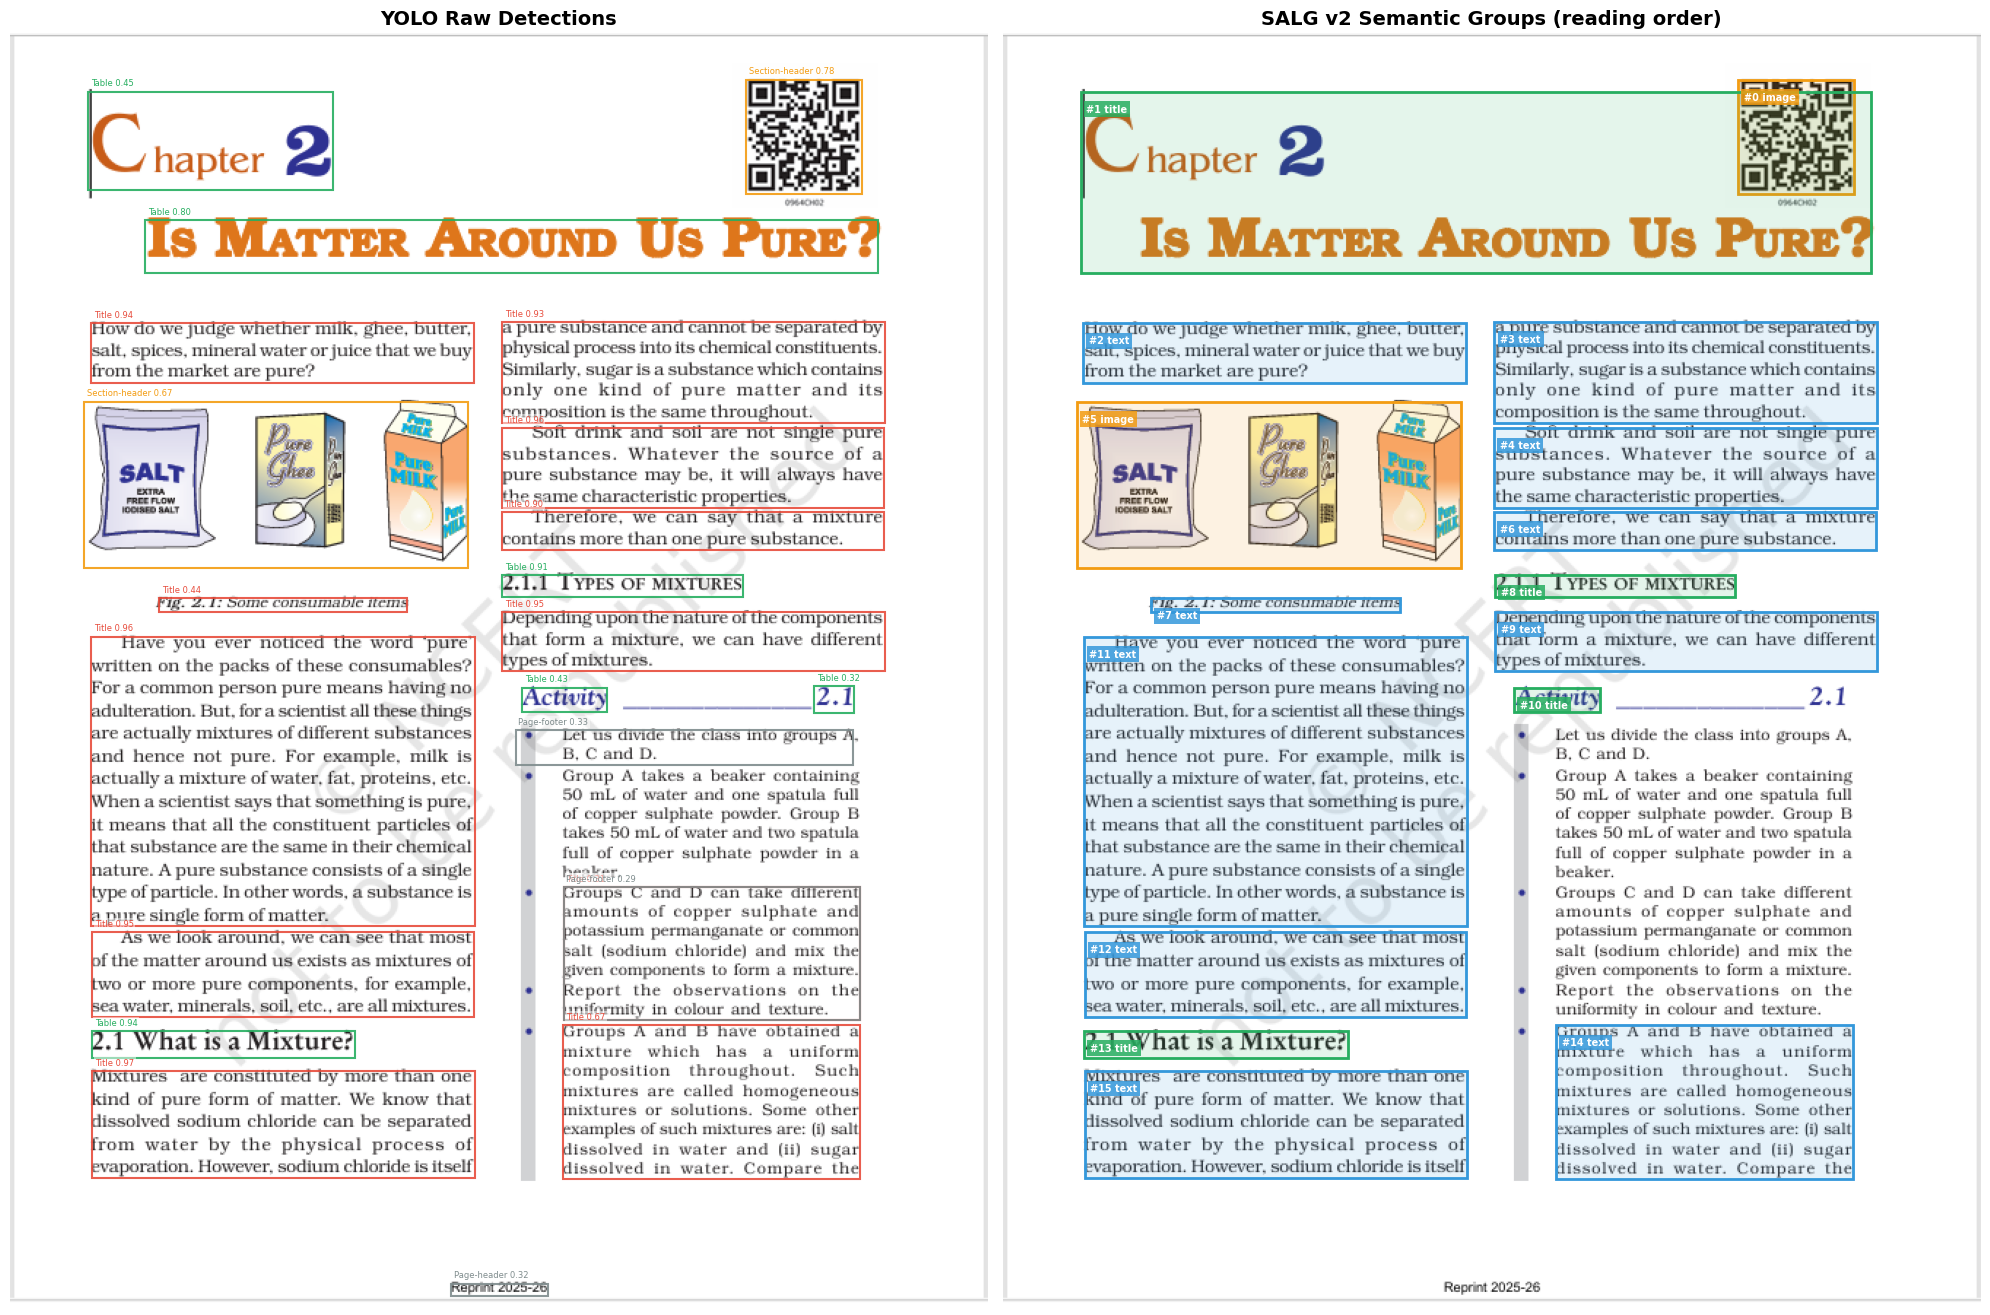

Saved: /content/outputs/salg_visualization.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

OUT_DIR = '/content/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

#  Rename group types
GROUP_REMAP = {
    'float'  : 'title',
    'title'  : 'text',
    'section': 'image',
    'flow':'table'
}
for g in groups:
    g.group_type = GROUP_REMAP.get(g.group_type, g.group_type)

#  Colors
COLORS = {
    'Text':'#4A90D9','Title':'#E74C3C','Section-header':'#F39C12',
    'Table':'#27AE60','Picture':'#8E44AD','Caption':'#16A085',
    'List-item':'#2980B9','Formula':'#D35400',
    'Page-header':'#7F8C8D','Page-footer':'#7F8C8D','Footnote':'#95A5A6',
}
GROUP_COLORS = {
    'text'            : '#3498DB',
    'title'           : '#27AE60',
    'image'           : '#F39C12',
    'flow'            : '#3498DB',
    'margin'          : '#95A5A6',
    'isolated_caption': '#BDC3C7',
}

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

ax = axes[0]
ax.imshow(img)
ax.set_title('YOLO Raw Detections', fontsize=14, fontweight='bold')
for det in detections:
    x1,y1,x2,y2 = det.box
    c = COLORS.get(det.cls_name, '#AAAAAA')
    ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth=1.5,edgecolor=c,facecolor='none',alpha=0.9))
    ax.text(x1+2,y1-4,f'{det.cls_name} {det.conf:.2f}',fontsize=6,color=c,
            bbox=dict(facecolor='white',alpha=0.5,pad=1,edgecolor='none'))
ax.axis('off')

ax = axes[1]
ax.imshow(img)
ax.set_title('SALG v2 Semantic Groups (reading order)', fontsize=14, fontweight='bold')
for g in groups:
    x1,y1,x2,y2 = g.bbox
    c = GROUP_COLORS.get(g.group_type,'#AAAAAA')
    ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth=2,edgecolor=c,facecolor=c,alpha=0.12))
    ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth=2,edgecolor=c,facecolor='none'))
    ax.text(x1+4,y1+14,f'#{g.reading_order} {g.group_type}',fontsize=7,color='white',fontweight='bold',
            bbox=dict(facecolor=c,alpha=0.85,pad=2,edgecolor='none'))
ax.axis('off')

plt.tight_layout()
save_path = f'{OUT_DIR}/salg_visualization.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## Export Structured JSON
- Converts semantic groups into JSON structure
- Stores reading order, group type, bounding box, and anchor info
- Includes all elements with class, confidence, and bbox
- Saves JSON output to file
- Prints sample of first few groups for preview

In [ ]:
import json

def groups_to_json(groups, img_path):
    return {
        'source_image' : img_path,
        'total_groups' : len(groups),
        'layout': [
            {
                'reading_order': g.reading_order,
                'type'         : g.group_type,
                'bbox'         : list(g.bbox),
                'anchor_class' : g.anchor.cls_name if g.anchor else None,
                'elements': [
                    {'class': e.cls_name, 'confidence': round(e.conf, 4), 'bbox': list(e.box)}
                    for e in g.elements
                ]
            }
            for g in groups
        ]
    }

json_output   = groups_to_json(groups, test_img_path)
json_save_path = f'{OUT_DIR}/salg_output.json'
with open(json_save_path, 'w') as f:
    json.dump(json_output, f, indent=2)

print(f'Saved: {json_save_path}')
print(json.dumps(json_output['layout'][:3], indent=2))

Saved: /content/outputs/salg_output.json
[
  {
    "reading_order": 0,
    "type": "image",
    "bbox": [
      503.74981689453125,
      31.614953994750977,
      583.1646728515625,
      110.31647491455078
    ],
    "anchor_class": null,
    "elements": [
      {
        "class": "Section-header",
        "confidence": 0.7781,
        "bbox": [
          503.74981689453125,
          31.614953994750977,
          583.1646728515625,
          110.31647491455078
        ]
      }
    ]
  },
  {
    "reading_order": 1,
    "type": "title",
    "bbox": [
      52.982601165771484,
      39.789947509765625,
      594.5955810546875,
      164.34861755371094
    ],
    "anchor_class": "Table",
    "elements": [
      {
        "class": "Table",
        "confidence": 0.7961,
        "bbox": [
          52.982601165771484,
          39.789947509765625,
          594.5955810546875,
          164.34861755371094
        ]
      }
    ]
  },
  {
    "reading_order": 2,
    "type": "text",
    "bb

In [19]:
from google.colab import files
files.download('/content/yolo26s_doclaynet_best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>